# Set-up

In [107]:
import os
import sys
import csv
import random
import torch
import pyfaidx
import numpy as np
import pandas as pd
import seaborn as sns
from tqdm.auto import tqdm
from scipy.stats import spearmanr, pearsonr

import hashlib

# Generate random 10 character hash
def create_run_hash():
    random_str = ''.join(random.choices('abcdefghijklmnopqrstuvwxyz0123456789', k=10))
    run_hash = hashlib.md5(random_str.encode()).hexdigest()[:10]
    return run_hash

import seqpro as sp

from ledidi import ledidi, Ledidi
from ledidi.pruning import greedy_pruning
from bpnetlite.bpnet import BPNet, CountWrapper, ProfileWrapper, ControlWrapper, _ProfileLogitScaling
from tangermeme.io import extract_loci
from tangermeme.predict import predict
from tangermeme.deep_lift_shap import deep_lift_shap, _nonlinear
from tangermeme.plot import plot_logo
from tangermeme.seqlet import recursive_seqlets
from tangermeme.annotate import annotate_seqlets
from tangermeme.io import read_meme

from matplotlib import pyplot as plt
import seaborn as sns; sns.set_style('white')

plt.rcParams["pdf.fonttype"] = 42
plt.rcParams["ps.fonttype"] = 42

# print tangermeme version
import tangermeme
print(tangermeme.__version__)

1.0.0


In [108]:
def log_softmax_profile(
    y_profile,
):
    # Log softmax the predicted profile
    z = y_profile.shape
    y_profile = y_profile.reshape(y_profile.shape[0], -1)
    y_profile = torch.nn.functional.log_softmax(y_profile, dim=-1)
    y_profile = y_profile.reshape(*z)
    return y_profile

In [109]:
os.chdir("/cellar/users/aklie/projects/igvf/ChromBetaNet")

In [110]:
path_out = "/cellar/users/aklie/projects/igvf/ChromBetaNet/scratch/2025_09_20"

# Load genome

In [111]:
chrom_sizes = "/cellar/users/aklie/data/ref/genomes/hg38/hg38.chrom.sizes"
chrom_sizes = pd.read_csv(chrom_sizes, header=None, sep='\t', names=['chrom', 'size'])
chrom_sizes_dict = chrom_sizes.set_index('chrom')['size'].to_dict()

In [112]:
genome_fasta = "/cellar/users/aklie/data/ref/genomes/hg38/hg38.fa"
genome = pyfaidx.Fasta(genome_fasta)

# Load peaks

In [113]:
# Load peaks
path_peaks = "/cellar/users/aklie/projects/igvf/ChromBetaNet/scratch/2025_09_05/peaks_with_predictions.tsv"
peaks = pd.read_csv(path_peaks, sep="\t")
peaks = peaks[peaks["log_counts_pred"] >= 0]
peaks.head()

,chrom,start,end,name,score,strand,signal_value,p_value,q_value,peak,log_counts,log_counts_pred
0,chr1,633840,634204,.,1000,.,40.609467,109236.929688,109228.906250,193,11.451295,4.753467
1,chr17,22521248,22521557,.,1000,.,43.419971,34642.917969,34635.835938,150,10.262176,4.971176
2,chr1,629813,630101,.,1000,.,8.402439,10337.239258,10330.491211,142,9.857549,3.479598
3,chr1,16612947,16614053,.,1000,.,25.223841,7114.754395,7108.110352,661,9.432923,8.318419
4,chr17,43251568,43251928,.,1000,.,46.463974,6077.647949,6071.098633,146,8.542471,8.081451


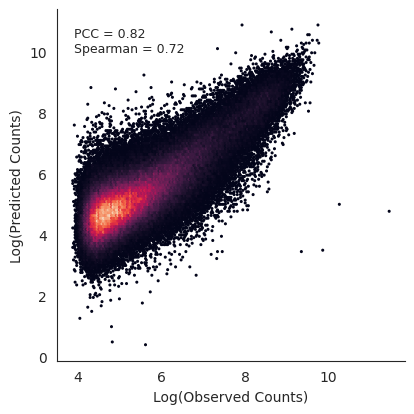

In [114]:
# Set up figure
fig, ax = plt.subplots(1, 1, figsize=(4.25, 4.25))

# Replace KDE with hexbin
ax.hexbin(
    peaks["log_counts"],
    peaks["log_counts_pred"],
    gridsize=200,
    mincnt=1,
    alpha=1
)

# Pearson r and spearman r
pcc_val, pcc_pval = pearsonr(peaks["log_counts_pred"], peaks["log_counts"])
spearman_val, spearman_pval = spearmanr(peaks["log_counts_pred"], peaks["log_counts"])

# Clean up plot
ax.spines[["top", "right"]].set_visible(False)
ax.set_xlabel("Log(Observed Counts)")
ax.set_ylabel("Log(Predicted Counts)")

# Top left annotation with stats
ax.text(
    0.05, 0.95,
    f"PCC = {pcc_val:.2f}\nSpearman = {spearman_val:.2f}",
    fontsize=9,
    transform=ax.transAxes,
    ha='left', va='top',
    bbox=dict(facecolor='white', alpha=0.8, edgecolor='none', pad=2)
)

# 
fig.tight_layout()

# Load motifs

In [115]:
path_motifs = "/cellar/users/aklie/data/datasets/sc-islet-differentiation_10X-Multiome/models/motifs/meme/combined.meme"
motifs = read_meme(path_motifs)
motif_names = np.array(list(motifs.keys()))

In [116]:
path_annot = "/cellar/users/aklie/data/datasets/sc-islet-differentiation_10X-Multiome/models/motifs/tfs_initial.txt"
tmp = pd.read_csv(path_annot, header=None, sep='\t', names=["motif_id", "annotated_tf", "evalue"])
motif_id_mp = tmp.set_index("motif_id")["annotated_tf"]

# Load model

In [117]:
path_model = "/cellar/users/aklie/data/datasets/sc-islet-differentiation_10X-Multiome/models/D15_ENP/fold_0/chrombpnet/0.5/models/chrombpnet_nobias.h5"
model = BPNet.from_chrombpnet(path_model).cuda().eval()
count_wrapper = CountWrapper(model).cuda().eval()

# Load sequences

In [118]:
# find the peaks that intersect with the NKX6-1 enhancer coordinates
def intersects_with_peak(row, peaks):
    chrom = row['chrom']
    start = row['start']
    end = row['end']
    
    # Filter peaks for the same chromosome
    chrom_peaks = peaks[peaks["chrom"] == chrom]
    
    # Check if any peak overlaps with the enhancer region
    for _, peak in chrom_peaks.iterrows():
        peak_start = peak["start"]
        peak_end = peak["end"]
        if not (end < peak_start or start > peak_end):  # No overlap condition
            return True
    return False

# and add the peak coordinates to the dataframe
def get_peak_coordinates(row, peaks):
    chrom = row['chrom']
    start = row['start']
    end = row['end']
    
    # Filter peaks for the same chromosome
    chrom_peaks = peaks[peaks["chrom"] == chrom]
    
    # Check if any peak overlaps with the enhancer region
    for _, peak in chrom_peaks.iterrows():
        peak_start = peak["start"]
        peak_end = peak["end"]
        if not (end < peak_start or start > peak_end):  # No overlap condition
            return f"{chrom}:{peak_start}-{peak_end}"
    return None

In [119]:
# Read in the headers from each sequence to get the coordinates
path_fasta = "scratch/2025_09_20/NKX6-1_CRE.fa"
seqs = pyfaidx.Fasta(path_fasta)
seq_headers = list(seqs.keys())[:-1]
nkx61_enhancer_df = pd.DataFrame(seq_headers, columns=['header'])
nkx61_enhancer_df['chrom'] = nkx61_enhancer_df['header'].str.split(':').str[0]
nkx61_enhancer_df['start'] = nkx61_enhancer_df['header'].str.split(':').str[1].str.split('-').str[0].astype(int)
nkx61_enhancer_df['end'] = nkx61_enhancer_df['header'].str.split(':').str[1].str.split('-').str[1].astype(int)
nkx61_enhancer_df['intersects_peak'] = nkx61_enhancer_df.apply(intersects_with_peak, peaks=peaks, axis=1)
nkx61_enhancer_df['peak_coordinates'] = nkx61_enhancer_df.apply(get_peak_coordinates, peaks=peaks, axis=1)
nkx61_enhancer_df["peak_chrom"] = nkx61_enhancer_df["peak_coordinates"].str.split(":").str[0]
nkx61_enhancer_df["peak_start"] = nkx61_enhancer_df["peak_coordinates"].str.split(":").str[1].str.split("-").str[0].astype(int)
nkx61_enhancer_df["peak_end"] = nkx61_enhancer_df["peak_coordinates"].str.split(":").str[1].str.split("-").str[1].astype(int)
nkx61_enhancer_df

,header,chrom,start,end,intersects_peak,peak_coordinates,peak_chrom,peak_start,peak_end
0,chr4:84432784-84434897,chr4,84432784,84434897,True,chr4:84433556-84434353,chr4,84433556,84434353


In [120]:
# Annote peaks as Enhancer_1, Enhancer_2, etc.
peaks_selected = peaks.merge(nkx61_enhancer_df[["peak_chrom", "peak_start", "peak_end"]], 
                                       left_on=["chrom", "start", "end"], 
                                       right_on=["peak_chrom", "peak_start", "peak_end"], 
                                       how="left", suffixes=("", "_enhancer"))
peaks_selected['CRE_annotation'] = np.where(
    peaks_selected['peak_chrom'].notnull(),
    'Enhancer',
    np.nan
)
peaks_selected['CRE_annotation'] = peaks_selected.groupby('chrom').cumcount() + 1
peaks_selected['CRE_annotation'] = np.where(
    peaks_selected['peak_chrom'].notnull(),
    'CRE_' + peaks_selected['CRE_annotation'].astype(str),
    np.nan
)

# Drop the temporary columns used for annotation
peaks_selected = peaks_selected.drop(columns=["peak_chrom", "peak_start", "peak_end"])
peaks_selected["CRE_annotation"].value_counts()

CRE_2518    1
Name: CRE_annotation, dtype: int64

In [121]:
# Get the deciles of the distribution
deciles = np.percentile(peaks_selected["log_counts_pred"].dropna(), [0, 5, 15, 25, 35, 45, 55, 65, 75, 85, 95, 100])
deciles

array([ 0.3704744 ,  3.92168246,  4.34471609,  4.60536172,  4.82451904,
        5.03627367,  5.2626063 ,  5.52310919,  5.86997775,  6.41905241,
        7.63897895, 10.879662  ])

In [122]:
# Which decile bin does each CRE belong to?
peaks_selected['decile'] = pd.cut(peaks_selected['log_counts_pred'], bins=deciles, labels=False)
peaks_selected["decile"].value_counts()

3.0     23371
4.0     23371
9.0     23371
8.0     23371
7.0     23371
6.0     23371
2.0     23371
1.0     23371
5.0     23370
10.0    11686
0.0     11685
Name: decile, dtype: int64

In [123]:
peaks_selected[~peaks_selected["CRE_annotation"].isna()]

,chrom,start,end,name,score,strand,signal_value,p_value,q_value,peak,log_counts,log_counts_pred,CRE_annotation,decile
60472,chr4,84433556,84434353,.,1000,.,8.957655,129.663162,127.419823,347,6.33328,5.847903,CRE_2518,7.0


In [ ]:
# Plot a beautiful histogram of the predictions 
with sns.plotting_context("notebook", font_scale=1.5):
    fig, ax = plt.subplots(figsize=(8, 4))

    # Plot forward
    sns.histplot(
        peaks_selected["log_counts_pred"],
        bins=50,
        kde=True,
        color='blue',
        label='Predicted Counts',
        ax=ax
    )

    # Plot each NKX6-1 CRE as a vertical line each with a different color
    CRE_colors = sns.color_palette("husl", peaks_selected["CRE_annotation"].nunique())
    for i, (CRE_name, group) in enumerate(peaks_selected.groupby("CRE_annotation")):
        if CRE_name.startswith("CRE_"):
            CRE_color = CRE_colors[i % len(CRE_colors)]
            #Grab chr:start-end for label
            locus = f"{group['chrom'].iloc[0]}:{group['start'].iloc[0]}-{group['end'].iloc[0]}"
            ax.axvline(
                x=group["log_counts_pred"].mean(),
                color=CRE_color,
                linestyle='--',
                linewidth=2,
                label=locus
            )

    # Move legend outside of the plot
    ax.legend(loc='upper left', bbox_to_anchor=(1, 1))
    plt.xlabel('Log(Tn5 insertion)')
    plt.ylabel('Frequency')
    plt.xticks(rotation=45)

    # 
    plt.tight_layout()

In [ ]:
# Plot a beautiful histogram of the predictions with deciles
with sns.plotting_context("notebook", font_scale=1.5):
    fig, ax = plt.subplots(figsize=(8, 4))

    # Plot forward
    sns.histplot(
        peaks_selected["log_counts_pred"],
        bins=50,
        kde=True,
        color='blue',
        label='Predicted Counts',
        ax=ax
    )

    # Plot each NKX6-1 CRE as a vertical line each with a different color
    CRE_colors = sns.color_palette("husl", peaks_selected["CRE_annotation"].nunique())
    for i, (CRE_name, group) in enumerate(peaks_selected.groupby("CRE_annotation")):
        if CRE_name.startswith("CRE_"):
            CRE_color = CRE_colors[i % len(CRE_colors)]
            #Grab chr:start-end for label
            locus = f"{group['chrom'].iloc[0]}:{group['start'].iloc[0]}-{group['end'].iloc[0]}"
            ax.axvline(
                x=group["log_counts_pred"].mean(),
                color=CRE_color,
                linestyle='--',
                linewidth=2,
                label=locus
            )

    # Add vertical lines for deciles
    for decile in deciles:
        ax.axvline(decile, color='red', linestyle='-', linewidth=1)

    # Move legend outside of the plot
    #ax.legend(loc='lower center', bbox_to_anchor=(1, 1))
    plt.xlabel('Log(Tn5 insertion)')
    plt.ylabel('Frequency')
    plt.xticks(rotation=45)

    # 
    plt.tight_layout()

# CRE design

In [ ]:
MPRA_integrated_sequence_2 = "gggtctctctggttagaccagatctgagcctgggagctctctggctaactagggaacccactgcttaagcctcaataaagcttgccttgagtgcttcaagtagtgtgtgcccgtctgttgtgtgactctggtaactagagatccctcagacccttttagtcagtgtggaaaatctctagcagtggcgcccgaacagggacttgaaagcgaaagggaaaccagaggagctctctcgacgcaggactcggcttgctgaagcgcgcacggcaagaggcgaggggcggcgactggtgagtacgccaaaaattttgactagcggaggctagaaggagagagatgggtgcgagagcgtcagtattaagcgggggagaattagatcgcgatgggaaaaaattcggttaaggccagggggaaagaaaaaatataaattaaaacatatagtatgggcaagcagggagctagaacgattcgcagttaatcctggcctgttagaaacatcagaaggctgtagacaaatactgggacagctacaaccatcccttcagacaggatcagaagaacttagatcattatataatacagtagcaaccctctattgtgtgcatcaaaggatagagataaaagacaccaaggaagctttagacaagatagaggaagagcaaaacaaaagtaagaccaccgcacagcaagcggccggccgctgatcttcagacctggaggaggagatatgagggacaattggagaagtgaattatataaatataaagtagtaaaaattgaaccattaggagtagcacccaccaaggcaaagagaagagtggtgcagagagaaaaaagagcagtgggaataggagctttgttccttgggttcttgggagcagcaggaagcactatgggcgcagcgtcaatgacgctgacggtacaggccagacaattattgtctggtatagtgcagcagcagaacaatttgctgagggctattgaggcgcaacagcatctgttgcaactcacagtctggggcatcaagcagctccaggcaagaatcctggctgtggaaagatacctaaaggatcaacagctcctggggatttggggttgctctggaaaactcatttgcaccactgctgtgccttggaatgctagttggagtaataaatctctggaacagatttggaatcacacgacctggatggagtgggacagagaaattaacaattacacaagcttaatacactccttaattgaagaatcgcaaaaccagcaagaaaagaatgaacaagaattattggaattagataaatgggcaagtttgtggaattggtttaacataacaaattggctgtggtatataaaattattcataatgatagtaggaggcttggtaggtttaagaatagtttttgctgtactttctatagtgaatagagttaggcagggatattcaccattatcgtttcagacccacctcccaaccccgaggggacccgacaggcccgaaggaatagaagaagaaggtggagagagagacagagacagatccattcgattagtgaacggatcggcactgcgtgcgccaattctgcagacaaatggcagtattcatccacaattttaaaagaaaaggggggattggggggtacagtgcaggggaaagaatagtagacataatagcaacagacatacaaactaaagaattacaaaaacaaattacaaaaattcaaaattttcgggtttattacagggacagcagagatccagtttggttagtaccgggcccggtgctttgctctgagccagcccaccagtttggaatgactcctttttatgacttgaattttcaagtataaagtctagtgctaaatttaatttgaacaactgtatagtttttgctggttgggggaaggaaaaaaaatggtggcagtgtttttttcagaattagaagtgaaatgaaaacttgttgtgtgtgaggatttctaatgacatgtggtggttgcatactgagtgaagccggtgagcattctgccatgtcaccccctcgtgctcagtaatgtactttacagaaatcctaaactcaaaagattgatataaaccatgcttcttgtgtatatccggtctcttctctgggtagtctcactcagcctgcatttctgccagggcccgctctagaccTGCAGGAATGCTAGCGCATGGNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNCTGCAACCTACGGAACACTAGAGGGTATATAATGGAAGCTCGACTTCCAGCTTGGCAATCCGGTACTGTGCAAAGTGAACACATCGCTAAGCGAAAGCTAAGNNNNNNNNNNNNNNNACCGGtcgccaccatggtgagcaagggcgaggagctgttcaccggggtggtgcccatcctggtcgagctggacggcgacgtaaacggccacaagttcagcgtgtccggcgagggcgagggcgatgccacctacggcaagctgaccctgaagttcatctgcaccaccggcaagctgcccgtgccctggcccaccctcgtgaccaccctgacctacggcgtgcagtgcttcagccgctaccccgaccacatgaagcagcacgacttcttcaagtccgccatgcccgaaggctacgtccaggagcgcaccatcttcttcaaggacgacggcaactacaagacccgcgccgaggtgaagttcgagggcgacaccctggtgaaccgcatcgagctgaagggcatcgacttcaaggaggacggcaacatcctggggcacaagctggagtacaactacaacagccacaacgtctatatcatggccgacaagcagaagaacggcatcaaggtgaacttcaagatccgccacaacatcgaggacggcagcgtgcagctcgccgaccactaccagcagaacacccccatcggcgacggccccgtgctgctgcccgacaaccactacctgagcacccagtccgccctgagcaaagaccccaacgagaagcgcgatcacatggtcctgctggagttcgtgaccgccgccgggatcactctcggcatggacgagctgtacaagtaggaattcgtcgagggacctaataacttcgtatagcatacattatacgaagttatacatgtttaagggttccggttccactaggtacaattcgatatcaagcttatcgataatcaacctctggattacaaaatttgtgaaagattgactggtattcttaactatgttgctccttttacgctatgtggatacgctgctttaatgcctttgtatcatgctattgcttcccgtatggctttcattttctcctccttgtataaatcctggttgctgtctctttatgaggagttgtggcccgttgtcaggcaacgtggcgtggtgtgcactgtgtttgctgacgcaacccccactggttggggcattgccaccacctgtcagctcctttccgggactttcgctttccccctccctattgccacggcggaactcatcgccgcctgccttgcccgctgctggacaggggctcggctgttgggcactgacaattccgtggtgttgtcggggaaatcatcgtcctttccttggctgctcgcctgtgttgccacctggattctgcgcgggacgtccttctgctacgtcccttcggccctcaatccagcggaccttccttcccgcggcctgctgccggctctgcggcctcttccgcgtcttcgccttcgccctcagacgagtcggatctccctttgggccgcctccccgcatcgataccgtcgacctcgatcgagacctagaaaaacatggagcaatcacaagtagcaatacagcagctaccaatgctgattgtgcctggctagaagcacaagaggaggaggaggtgggttttccagtcacacctcaggtaccaagcatggggtaaagtactgttctcatcacatcatatcaaggttatataccatcaatattgccacagatgttacttagccttttaatatttctctaatttagtgtatatgcaatgatagttctctgatttctgagattgagtttctcatgtgtaatgattatttagagtttctctttcatctgttcaaatttttgtctagttttattttttactgatttgtaagacttctttttataatctgcatattacaattctctttactggggtgttgcaaatattttctgtcattctatggcctgacttttcttaatggttttttaattttaaaaataagtcttaatattcatgcaatctaattaacaatcttttctttgtggttaggactttgagtcataagaaatttttctctacactgaagtcatgatggcatgcttctatattattttctaaaagatttaaagttttgccttctccatttagacttataattcactggaatttttttgtgtgtatggtatgacatatgggttcccttttattttttacatataaatatatttccctgtttttctaaaaaagaaaaagatcatcattttcccattgtaaaatgccatatttttttcataggtcacttacatatatcaatgggtctgtttctgagctctactctattttatcagcctcactgtctatccccacacatctcatgctttgctctaaatcttgatatttagtggaacattctttcccattttgttctacaagaatatttttgttattgtcttttgggcttctatatacattttagaatgaggttggcaagttctgtagatcttagccactttttaaaagaaaaggggggactggaagggctaattcactcccaacgaagacaagatatccttgatctgtggatctaccacacacaaggctacttccctgattggcagaactacacaccagggccagggatcagatatccactgacctttggatggtgctacaagctagtaccagttgagcaagagaaggtagaagaagccaatgaaggagagaacacccgcttgttacaccctgtgagcctgcatgggatggatgacccggagagagaagtattagagtggaggtttgacagccgcctagcatttcatcacatggcccgagagctgcatccggactgtactgggtctctctggttagaccagatctgagcctgggagctctctggctaactagggaacccactgcttaagcctcaataaagcttgccttgagtgcttcaagtagtgtgtgcccgtctgttgtgtgactctggtaactagagatccctcagacccttttagtcagtgtggaaaatctctagca"
len(MPRA_integrated_sequence_2), MPRA_integrated_sequence_2.count('N')

In [ ]:
# Define model and ism params
seq_len = 2114
target_len = 1000
ism_window = 270
plot_window = 270

# Seq limits
seq_center = 2114 // 2
seq_start = seq_center - ism_window // 2
seq_end = seq_center + ism_window // 2

# Target limits
target_center = 1000 // 2
target_start = target_center - ism_window // 2
target_end = target_center + ism_window // 2

# Plot starts
plot_seq_center = 1057
plot_seq_start = seq_center - plot_window // 2
plot_seq_end = seq_center + plot_window // 2
plot_target_center = 500
plot_target_start = target_center - plot_window // 2
plot_target_end = target_center + plot_window // 2

print(f"seq_start: {seq_start}, seq_end: {seq_end}")
print(f"target_start: {target_start}, target_end: {target_end}")
print(f"plot_seq_start: {plot_seq_start}, plot_seq_end: {plot_seq_end}")
print(f"plot_target_start: {plot_target_start}, plot_target_end: {plot_target_end}")

In [ ]:
# Candidate
CRE_idx = 0

# Create run hash
run_hash = create_run_hash()
print(f"Run hash: {run_hash}")

In [78]:
# Prep
design_res = {}
CRE_ = peaks_selected[peaks_selected["CRE_annotation"].notnull()].iloc[CRE_idx]
idx_ = peaks_selected[peaks_selected["CRE_annotation"].notnull()].index[CRE_idx]
chrom_ = CRE_["chrom"]
start_ = CRE_["start"]
end_ = CRE_["end"]
summit_ = CRE_["peak"]
decile_ = CRE_["decile"]
preds_ = peaks_selected["log_counts_pred"].values[idx_]
percentil_ = np.sum(peaks_selected["log_counts_pred"] < preds_) / len(peaks_selected) * 100
print(f"Processing CRE: {chrom_}:{start_}-{end_}: {preds_}")
print(f"Decile: {decile_}, Percentile: {percentil_:.2f}")

plot_coordinate_start = start_ + summit_ - plot_window // 2
plot_coordinate_end = plot_coordinate_start + plot_window
print(f"Plotting coordinates: {chrom_}:{plot_coordinate_start}-{plot_coordinate_end}")

# Params
dtype = torch.float64
n_seqs = 10
n_runs = 1
prune = True
prune_threshold = 0.5

Processing CRE: chr4:84433556-84434353: 5.8479033
Decile: 7.0, Percentile: 74.46
Plotting coordinates: chr4:84433768-84434038


In [79]:
# Create directory to save
dir_name = f"NKX6-1_{chrom_}:{start_}-{end_}_Ledidi_design_{run_hash}"
os.makedirs(os.path.join(path_out, dir_name), exist_ok=True)

## Reference prediction

In [80]:
# Verify prediction
ref_seq_start = start_ + summit_ - seq_len // 2
ref_seq_end = ref_seq_start + seq_len
design_res["reference_locus"] = f"{chrom_}:{ref_seq_start}-{ref_seq_end}"
ref_seq = genome[chrom_][ref_seq_start:ref_seq_end].seq.upper()
design_res["reference_sequence"] = ref_seq
X_ref = torch.tensor(sp.ohe([ref_seq], alphabet=sp.DNA).transpose(0, 2, 1), dtype=torch.uint8)
y_ref = predict(
    model=count_wrapper.type(torch.float32),
    X=X_ref,
    verbose=True,   
)
design_res["reference_prediction"] = y_ref.item()
design_res

100%|██████████| 1/1 [00:00<00:00, 303.89it/s]


{'reference_locus': 'chr4:84432846-84434960',
 'reference_sequence': 'TTGATAGCCAGATGTGAAGGAGAATAGGAGACATTCTATTATTTGCAAAGCACCCAACTATGGTATGCTTAGTCACAAACAAAACATTTCAAGGAGAAGACTCCATTTCTAAGTTAGAAAAAAAATGTACACCTATAAACACTGATTCATTCTCTTCTCTCTGATGACAAACACTAAATTAGTCTATAAATTATGAGTATTATGTTTGTAGAGTACCCCCATGTTCTAACTACTCCACCTCTTTAATCAATTTGCCATTCCAAAATGGAAAATGATTTAGAAAAACCTGTCAAACAGAAGAGAAAGAAAATCTAATCTGGGCAAGTTATTAAGAAATCTGCTTCTTTGAATCTTTAACATTTAAACTGTCCATAGAGATTTAGAAATGAGGTGAGGGCAAGATGGAGGTGGGGTGGAGGCTTGGGGCACAGGGTGGGGGCTGCAAAGAGAGACTAGCTGCATCCCCAGAGCACCGGAGCACCGTCTAGCTTGGAAGAAGAATGGGAAGTTACACGTTGAGAGATAGAGAAAGAAGCAGAGACAGGTGGCAAAAAGAACAAGTATGAAACAGGCAGGAATACAGGAGGAAGACAAAGAAGAACATGAAAAGTGGAGGAAAAAACAATGAGAAGTAGAGAAGGAGTCATGAGAGGAGAAAGGGGGAACCGAGGGAGCCTGCGGGGAAGAATGAAAAGAAGGGAAACTAAGAGAGAAAAAGAACAGCTCCTCCATCATCGGTGCTGCCTTCTTCATCTTCGTCTCTTTTTTTTTTCAGATGGCACACTGACAGAAGATTAATTCAAGTCAGCTGCTGAAAATAATTATTGCATTATGGGAGCAGTAATCATTATTTAGAACATGATTAAATATGTCTGCACCTATTGACTCTGCCTATGATTTATGTATTTGTTTAGTCAATAGTCTAATGTA

## Ledidi design

In [81]:
# Create boolean tensor mask where the middle 270 are 0 and the rest are 1
msk = torch.ones(1, seq_len, dtype=torch.bool)
msk[:, seq_start:seq_end] = 0
msk = msk.reshape(-1)
msk.sum()

tensor(1844)

In [82]:
# Get a list of all deciles above decile_
deciles_above = deciles[int(decile_)+1:]
print(f"Deciles above {decile_}: {deciles_above}")

# Get a list of all deciles below decile_
deciles_below = deciles[:int(decile_)+1][1:]
print(f"Deciles below {decile_}: {deciles_below}")

# Create y_bars for above deciles with +prune_threshold and below deciles with -prune_threshold
y_bars = [torch.zeros(1, dtype=torch.float32) + d - prune_threshold for d in deciles_below] + [torch.zeros(1, dtype=torch.float32) + d + prune_threshold for d in deciles_above]
y_bars

Deciles above 7.0: [ 5.86997775  6.41905241  7.63897895 10.879662  ]
Deciles below 7.0: [3.92168246 4.34471609 4.60536172 4.82451904 5.03627367 5.2626063
 5.52310919]


[tensor([3.4217]),
 tensor([3.8447]),
 tensor([4.1054]),
 tensor([4.3245]),
 tensor([4.5363]),
 tensor([4.7626]),
 tensor([5.0231]),
 tensor([6.3700]),
 tensor([6.9191]),
 tensor([8.1390]),
 tensor([11.3797])]

In [83]:
# Run ledidi
X_hat = []
for y_bar in tqdm(y_bars, desc="Running Ledidi for each decile"):
    print(f"Running Ledidi for decile target: {y_bar.item()}")
    X_hat_ = []
    for i in tqdm(range(n_runs)):
        X_hat_.append(ledidi(count_wrapper.type(torch.float32), X_ref.type(torch.float32), y_bar, n_samples=n_seqs, input_mask=msk, verbose=True))
    X_hat.append(X_hat_)
X_hat = [torch.stack(x_hat_) for x_hat_ in X_hat]
X_hat = torch.stack(X_hat)
X_hat.shape

Running Ledidi for each decile:   0%|          | 0/11 [00:00<?, ?it/s]

Running Ledidi for decile target: 3.421682357788086


  0%|          | 0/1 [00:00<?, ?it/s]

/cellar/users/aklie/opt/miniconda3/envs/eugene_tools/lib/python3.11/site-packages/torch/nn/modules/loss.py:538: UserWarning: Using a target size (torch.Size([1])) that is different to the input size (torch.Size([1, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


iter=I	input_loss=0.0	output_loss=5.595	total_loss=5.595	time=0.0


...

  0%|          | 0/1 [00:00<?, ?it/s]

iter=I	input_loss=0.0	output_loss=5.532	total_loss=5.532	time=0.0
iter=100	input_loss=14.5	output_loss=0.08008	total_loss=1.53	time=3.585
iter=200	input_loss=13.38	output_loss=0.08388	total_loss=1.421	time=3.584
iter=300	input_loss=13.38	output_loss=0.06183	total_loss=1.399	time=3.587
iter=F	input_loss=10.44	output_loss=0.03404	total_loss=1.078	time=12.94
Running Ledidi for decile target: 11.379661560058594


  0%|          | 0/1 [00:00<?, ?it/s]

iter=I	input_loss=0.0	output_loss=31.28	total_loss=31.28	time=0.0
iter=100	input_loss=44.75	output_loss=0.3841	total_loss=4.859	time=3.59
iter=200	input_loss=27.88	output_loss=0.06957	total_loss=2.857	time=3.589
iter=300	input_loss=36.12	output_loss=0.2538	total_loss=3.866	time=3.589
iter=F	input_loss=26.94	output_loss=0.03435	total_loss=2.728	time=13.64


torch.Size([11, 1, 10, 4, 2114])

In [84]:
# Create identifiers for each of X_hat based on NKX6-1_{chrom_}:{start_}-{end_}_Ledidi_run_{run}_decile_{decile}
identifiers = []
for decile in range(X_hat.shape[0]):
    for run in range(X_hat.shape[1]):
        for t, seq in enumerate(range(X_hat.shape[2])):
            identifiers.append(f"NKX6-1_{chrom_}:{start_}-{end_}_Ledidi_run-{run+1}_target-{round(y_bars[decile].item()-prune_threshold, 2)}_{t+1}")

In [85]:
# Stack the everything but the last two dims
X_optim = X_hat.view(-1, X_hat.shape[-2], X_hat.shape[-1])
X_optim.shape

torch.Size([110, 4, 2114])

## Pruning

In [86]:
# Repeat the above for every index of X_optim
if prune == True:
    print("Pruning X_optim with greedy pruning")
    X_optim_p = []
    for i in tqdm(range(len(X_optim)), desc="Pruning X_optim"):
        X_optim_p.append(greedy_pruning(
            count_wrapper.type(torch.float32),
            X=X_ref.cuda(),
            X_hat=X_optim[i:i+1].cuda(),
            verbose=False,
            threshold=prune_threshold
        ))
    X_optim_p = torch.stack(X_optim_p).squeeze(dim=1)
    y_hat_p = predict(
        model=count_wrapper.type(torch.float32),
        X=X_optim_p.type(torch.uint8),
        verbose=True,
        ).squeeze(dim=1)
    X_optim = X_optim_p
    y_hat = y_hat_p
else:
    print("Not pruning X_optim")

Pruning X_optim with greedy pruning


Pruning X_optim:   0%|          | 0/110 [00:00<?, ?it/s]

100%|██████████| 4/4 [00:01<00:00,  2.32it/s]


100%|██████████| 1/1 [00:00<00:00,  2.49it/s]


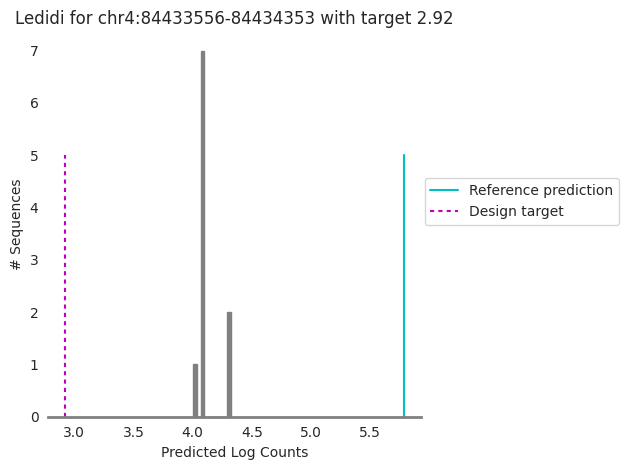

100%|██████████| 1/1 [00:00<00:00, 79.89it/s]


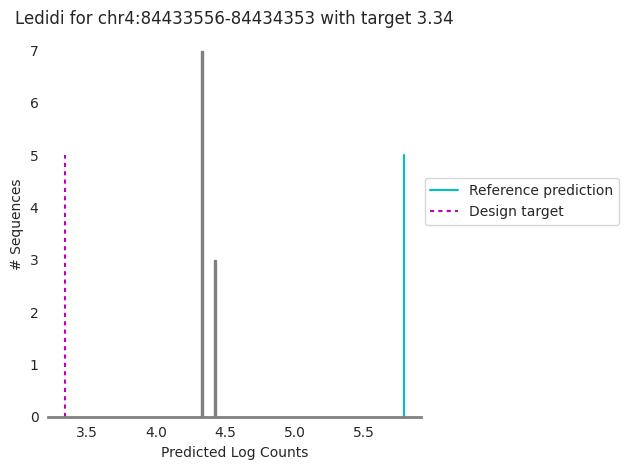

100%|██████████| 1/1 [00:00<00:00, 80.21it/s]


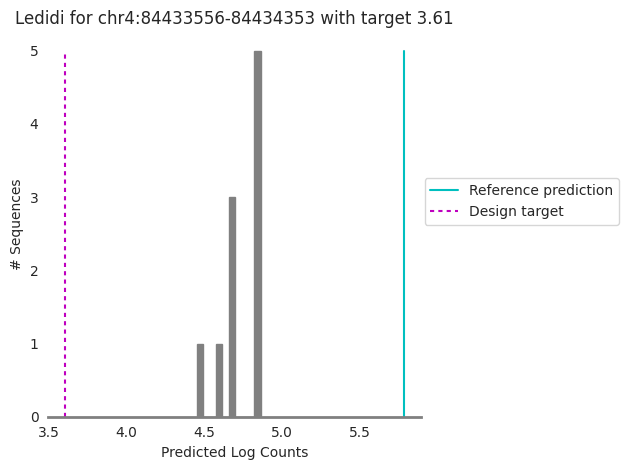

100%|██████████| 1/1 [00:00<00:00, 80.57it/s]


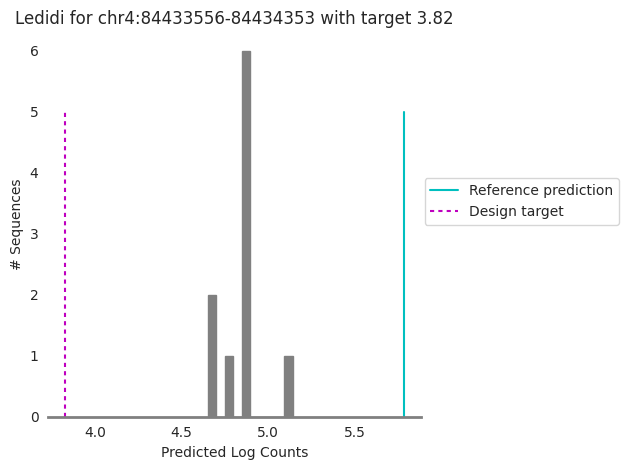

100%|██████████| 1/1 [00:00<00:00, 80.28it/s]


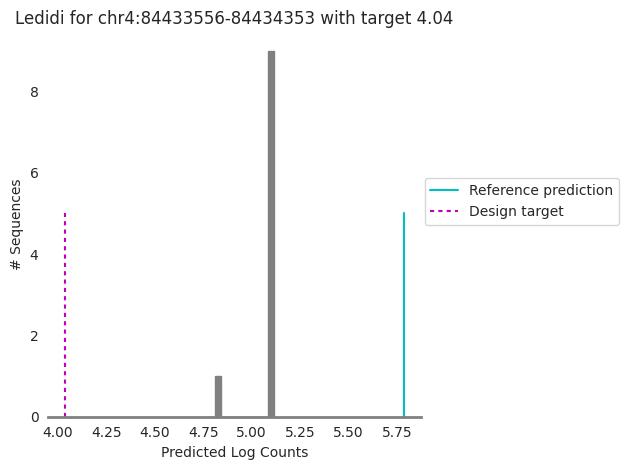

100%|██████████| 1/1 [00:00<00:00, 59.97it/s]


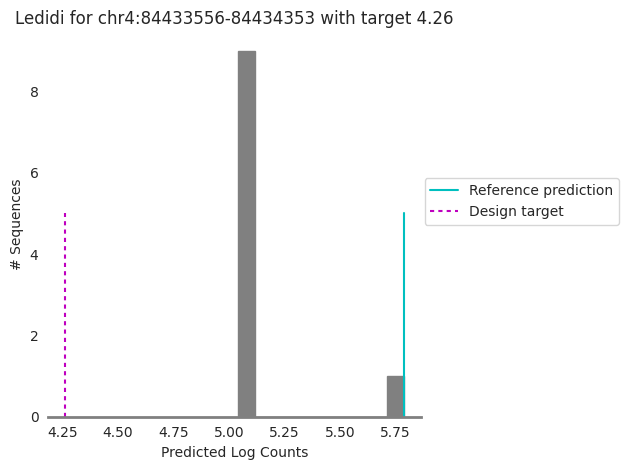

100%|██████████| 1/1 [00:00<00:00, 59.53it/s]


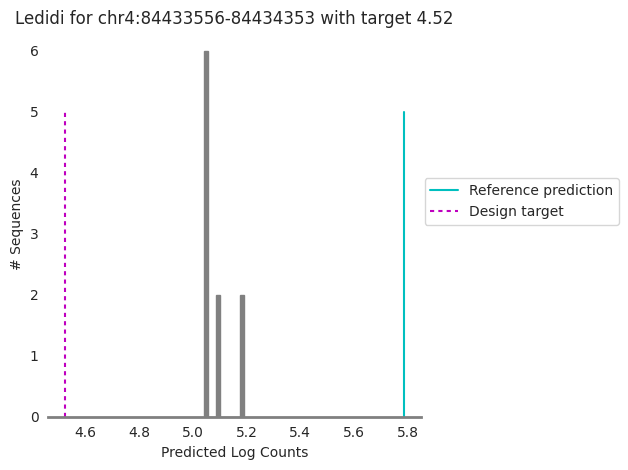

100%|██████████| 1/1 [00:00<00:00, 59.87it/s]


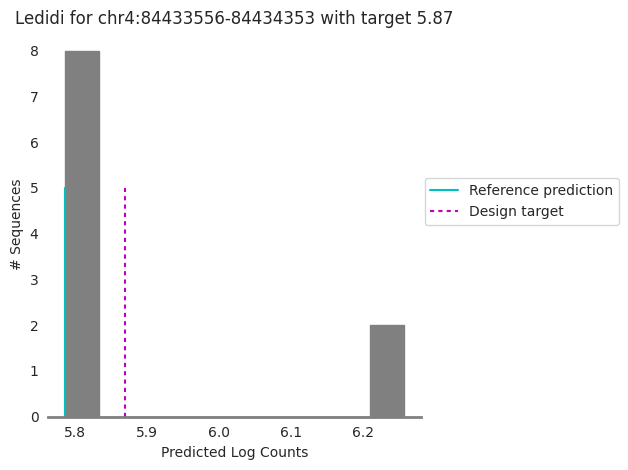

100%|██████████| 1/1 [00:00<00:00, 60.15it/s]


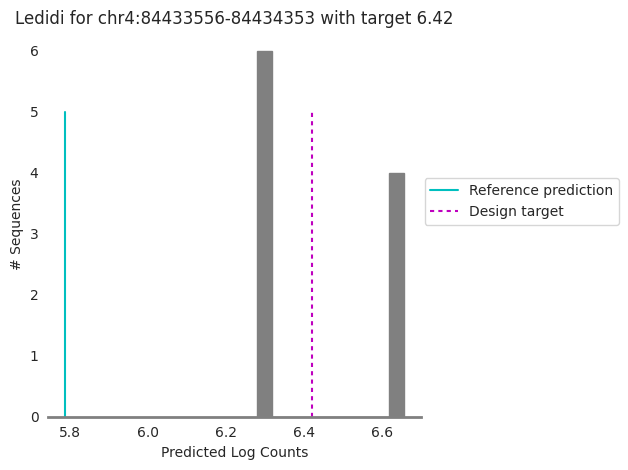

100%|██████████| 1/1 [00:00<00:00, 60.05it/s]


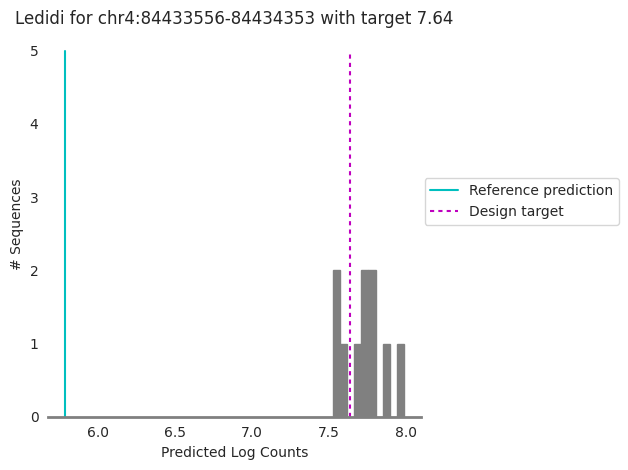

100%|██████████| 1/1 [00:00<00:00, 59.79it/s]


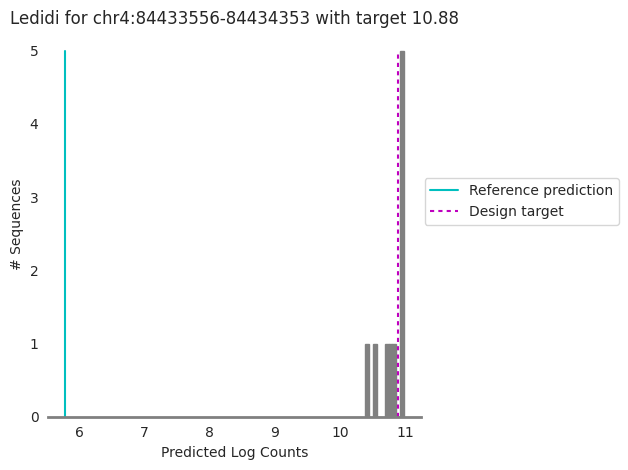

In [87]:
y_hat = []
for j, y_bar in enumerate(y_bars):
    y0 = y_ref.numpy(force=True)[0, 0]
    batch_size = n_runs * n_seqs
    X_hat = X_optim[j*batch_size:(j+1)*batch_size]
    ax = plt.subplot(111)
    y_hat_ = predict(
        model=count_wrapper.type(torch.float32),
        X=X_hat,
        verbose=True,
    )
    plt.hist(y_hat_, facecolor='0.5', edgecolor='0.5')
    y_hat.append(y_hat_)
    plt.plot([y0, y0], [0, 5], label="Reference prediction", c='c')
    plt.plot([y_bar-prune_threshold, y_bar-prune_threshold], [0, 5], label="Design target", c='m', linestyle=(0, (2, 2)))
    plt.title(f"Ledidi for {chrom_}:{start_}-{end_} with target {round(y_bar.item()-prune_threshold, 2)}")
    plt.legend(loc=(1.01, 0.5))
    plt.xlabel("Predicted Log Counts")
    plt.ylabel("# Sequences")
    sns.despine(left=True)
    plt.grid(False)
    plt.setp(ax.spines.values(), linewidth=2, color='0.5')
    plt.tight_layout()
    plt.savefig(os.path.join(path_out, dir_name, f"NKX6-1_{chrom_}:{start_}-{end_}_Ledidi_design_target_{round(y_bar.item()-prune_threshold, 2)}_{run_hash}.pdf"), dpi=300)
    plt.show()
y_hat = torch.stack(y_hat).squeeze()
y_hat = y_hat.view(-1)

In [88]:
# Grab actual string sequences
optim_seqs = sp.decode_ohe(X_optim.detach().cpu().numpy().astype(np.uint8), alphabet=sp.DNA, ohe_axis=1)
optim_seqs = [b''.join(optim_seq).decode('utf-8') for optim_seq in optim_seqs]
optim_seqs[:5]

['TTGATAGCCAGATGTGAAGGAGAATAGGAGACATTCTATTATTTGCAAAGCACCCAACTATGGTATGCTTAGTCACAAACAAAACATTTCAAGGAGAAGACTCCATTTCTAAGTTAGAAAAAAAATGTACACCTATAAACACTGATTCATTCTCTTCTCTCTGATGACAAACACTAAATTAGTCTATAAATTATGAGTATTATGTTTGTAGAGTACCCCCATGTTCTAACTACTCCACCTCTTTAATCAATTTGCCATTCCAAAATGGAAAATGATTTAGAAAAACCTGTCAAACAGAAGAGAAAGAAAATCTAATCTGGGCAAGTTATTAAGAAATCTGCTTCTTTGAATCTTTAACATTTAAACTGTCCATAGAGATTTAGAAATGAGGTGAGGGCAAGATGGAGGTGGGGTGGAGGCTTGGGGCACAGGGTGGGGGCTGCAAAGAGAGACTAGCTGCATCCCCAGAGCACCGGAGCACCGTCTAGCTTGGAAGAAGAATGGGAAGTTACACGTTGAGAGATAGAGAAAGAAGCAGAGACAGGTGGCAAAAAGAACAAGTATGAAACAGGCAGGAATACAGGAGGAAGACAAAGAAGAACATGAAAAGTGGAGGAAAAAACAATGAGAAGTAGAGAAGGAGTCATGAGAGGAGAAAGGGGGAACCGAGGGAGCCTGCGGGGAAGAATGAAAAGAAGGGAAACTAAGAGAGAAAAAGAACAGCTCCTCCATCATCGGTGCTGCCTTCTTCATCTTCGTCTCTTTTTTTTTTCAGATGGCACACTGACAGAAGATTAATTCAAGTCAGCTGCTGAAAATAATTATTGCATTATGGGAGCAGTAATCATTATTTAGAACATGATTAAATATGTCTGCACCTATTGACTCTGCCTATGATTTATGTATTTGTTTAGTCAATAGTATAATATAAATGATGTAATTAATTATAGATGGTGGTGTCAGGACATTGGTGAAAACAATCTGAGGAGAACAAGGGC

## Calculate attributions and call seqlets

In [89]:
# Get attribution scores for the original sequence
X_ref_attr_ = deep_lift_shap(
    count_wrapper.type(dtype), 
    X=X_ref.type(dtype),
    n_shuffles=20,
    batch_size=16,
    verbose=True,
    warning_threshold=1e-4
)
X_ref_attr_.shape

100%|██████████| 20/20 [00:28<00:00,  1.44s/it]


torch.Size([1, 4, 2114])

In [90]:
# Get attribution scores for the original sequence
X_optim_attr_ = deep_lift_shap(
    count_wrapper.type(dtype), 
    X=X_optim.type(dtype),
    n_shuffles=20,
    batch_size=16,
    verbose=True,
    warning_threshold=1e-4
)
X_optim_attr_.shape

100%|██████████| 2200/2200 [01:31<00:00, 24.10it/s]


torch.Size([110, 4, 2114])

In [91]:
# Save attribution scores to npz
np.savez_compressed(os.path.join(path_out, dir_name, f"NKX6-1_{chrom_}:{start_}-{end_}_Ledidi_X_ref_attr_{run_hash}.npz"), X_ref_attr=X_ref_attr_.numpy(force=True))
np.savez_compressed(os.path.join(path_out, dir_name, f"NKX6-1_{chrom_}:{start_}-{end_}_Ledidi_X_optim_attr_{run_hash}.npz"), X_optim_attr=X_optim_attr_.numpy(force=True))

In [92]:
# Call and annotate seqlets
X_attr_ = torch.cat([X_ref_attr_, X_optim_attr_], dim=0)
total_attr_mp = pd.Series(index=["NKX6-1_chr5:51382751-51383709_ref_sequence"] + identifiers, data=torch.abs(X_attr_).sum(dim=(-2, -1)).numpy())
X_ = torch.cat([X_ref.cpu(), X_optim.cpu()], dim=0)
seqlets = recursive_seqlets(X_attr_[:, :, seq_start:seq_end].sum(dim=1).detach(), threshold=0.05, additional_flanks=5)
motif_idxs = annotate_seqlets(X_[:, :, seq_start:seq_end].detach().cpu(), seqlets, path_motifs)[0][:, 0]
seqlets['start'] += seq_start
seqlets['end'] += seq_start
motifs_ = motif_id_mp.loc[motif_names[motif_idxs]]
seqlets["annotation"] = motifs_.values
seqlets["id"] = [(["NKX6-1_chr5:51382751-51383709_ref_sequence"] + identifiers)[idx] for idx in seqlets["example_idx"]]

# calcualte the proportion of total attribution for each seqlet
seqlets["attribution_proportion"] = seqlets["attribution"].abs() / seqlets["id"].map(total_attr_mp)
seqlets.head()

,example_idx,start,end,attribution,p-value,annotation,id,attribution_proportion
0,104,1083,1118,2.307076,8.099591e-07,HNF6_HUMAN.H11MO.0.B,NKX6-1_chr4:84433556-84434353_Ledidi_run-1_tar...,0.244790
1,105,1083,1118,2.112026,1.885312e-06,HNF6_HUMAN.H11MO.0.B,NKX6-1_chr4:84433556-84434353_Ledidi_run-1_tar...,0.226388
2,110,1094,1121,1.432667,3.377933e-06,FOXA2_HUMAN.H11MO.0.A,NKX6-1_chr4:84433556-84434353_Ledidi_run-1_tar...,0.151807
3,106,1094,1116,1.179935,9.366465e-06,FOXA2_HUMAN.H11MO.0.A,NKX6-1_chr4:84433556-84434353_Ledidi_run-1_tar...,0.116995
4,101,1094,1121,1.469375,1.690054e-05,FOXA2_HUMAN.H11MO.0.A,NKX6-1_chr4:84433556-84434353_Ledidi_run-1_tar...,0.160370


In [93]:
# Save
seqlets[["id", "start", "end", "attribution", "p-value", "annotation"]].sort_values(["id", "start"]).to_csv(
    os.path.join(path_out, dir_name, f"NKX6-1_{chrom_}:{start_}-{end_}_Ledidi_seqlets_{run_hash}.tsv"), 
    sep="\t", 
    index=False
)

In [94]:
def overlap_len(a_start, a_end, b_start, b_end):
    return max(0, min(a_end, b_end) - max(a_start, b_start))

def greedy_match(curr_design_df, baseline_df):
    cand = (
        curr_design_df.reset_index().merge(
            baseline_df.reset_index(),
            on="annotation",
            suffixes=("_d","_b")
        )
    )
    if cand.empty:
        return [], set(), set()

    cand["overlap"] = cand.apply(
        lambda r: overlap_len(r["start_d"], r["end_d"], r["start_b"], r["end_b"]),
        axis=1
    )
    cand = cand[cand["overlap"] > 0]
    if cand.empty:
        return [], set(), set()

    cand["start_gap"] = (cand["start_d"] - cand["start_b"]).abs()
    cand = cand.sort_values(["overlap","start_gap"], ascending=[False,True])

    used_d, used_b, matches = set(), set(), []
    for _, r in cand.iterrows():
        di, bi = r["index_d"], r["index_b"]
        if di not in used_d and bi not in used_b:
            used_d.add(di); used_b.add(bi)
            matches.append((di, bi))
    return matches, used_d, used_b

In [95]:
ref_seqlets = seqlets[seqlets["id"].str.contains("_ref_sequence")].copy()
designs_seqlets  = seqlets[~seqlets["id"].str.contains("_ref_sequence")].copy()
ref_seqlets.shape, designs_seqlets["id"].nunique()

((1, 8), 42)

In [96]:
# Build delta-seqlets once (designs_seqlets vs ref_seqlets)
rows = []

for design_id, curr_design_df in designs_seqlets.groupby("id", sort=False):
    # work on copies to avoid SettingWithCopy surprises
    d = curr_design_df[["start","end","attribution","attribution_proportion","p-value","annotation"]].copy()
    b = ref_seqlets[      ["start","end","attribution","attribution_proportion","p-value","annotation"]].copy()

    # ensure numeric
    d["start"] = d["start"].astype(int);  d["end"] = d["end"].astype(int);  d["attribution"] = d["attribution"].astype(float)
    b["start"] = b["start"].astype(int);  b["end"] = b["end"].astype(int);  b["attribution"] = b["attribution"].astype(float)

    matches, used_d, used_b = greedy_match(d, b)

    # matched → increase/decrease
    for di, bi in matches:
        drow, brow = d.loc[di], b.loc[bi]
        delta_attr = float(drow["attribution"]) - float(brow["attribution"])
        change_type = "increase" if delta_attr > 0 else ("decrease" if delta_attr < 0 else "increase")
        rows.append({
            "id": design_id,
            "start": int(drow["start"]),
            "end": int(drow["end"]),
            "attribution": float(drow["attribution"]),
            "p-value": float(drow["p-value"]),
            "attribution_proportion": float(drow["attribution_proportion"]),
            "delta_attribution": float(delta_attr),
            "type": change_type,
            "annotation": drow["annotation"],
        })

    # additions → present in design only
    if len(d) > 0 and len(used_d) > 0:
        d_unmatched = d.drop(index=list(used_d))
    else:
        d_unmatched = d if len(d) else d.iloc[0:0]
    for _, drow in d_unmatched.iterrows():
        rows.append({
            "id": design_id,
            "start": int(drow["start"]),
            "end": int(drow["end"]),
            "attribution": float(drow["attribution"]),
            "p-value": float(drow["p-value"]),
            "attribution_proportion": float(drow["attribution_proportion"]),
            "delta_attribution": float(drow["attribution"]),
            "type": "addition",
            "annotation": drow["annotation"],
        })

    # removals → present in ref only
    if len(b) > 0 and len(used_b) > 0:
        b_unmatched = b.drop(index=list(used_b))
    else:
        b_unmatched = b if len(b) else b.iloc[0:0]
    for _, brow in b_unmatched.iterrows():
        rows.append({
            "id": design_id,
            "start": int(brow["start"]),
            "end": int(brow["end"]),
            "attribution": float("nan"),
            "p-value": float("nan"),
            "attribution_proportion": float("nan"),
            "delta_attribution": -float(brow["attribution"]),
            "type": "removal",
            "annotation": brow["annotation"],
        })

delta_seqlets_all = pd.DataFrame(rows)
delta_seqlets_all["type"] = pd.Categorical(
    delta_seqlets_all["type"],
    categories=["increase","decrease","addition","removal"],
    ordered=True,
)
delta_seqlets_all.head()

,id,start,end,attribution,p-value,attribution_proportion,delta_attribution,type,annotation
0,NKX6-1_chr4:84433556-84434353_Ledidi_run-1_tar...,1166,1191,1.069906,9.007865e-03,0.113521,0.432278,increase,RFX6_MOUSE.H11MO.0.C
1,NKX6-1_chr4:84433556-84434353_Ledidi_run-1_tar...,1083,1118,2.307076,8.099591e-07,0.244790,2.307076,addition,HNF6_HUMAN.H11MO.0.B
2,NKX6-1_chr4:84433556-84434353_Ledidi_run-1_tar...,1113,1148,1.755283,2.496369e-02,0.186243,1.755283,addition,ETV6_MOUSE.H11MO.0.C
3,NKX6-1_chr4:84433556-84434353_Ledidi_run-1_tar...,1070,1093,1.202589,2.791437e-02,0.127600,1.202589,addition,NDF2_MOUSE.H11MO.0.A
4,NKX6-1_chr4:84433556-84434353_Ledidi_run-1_tar...,1139,1153,0.312607,3.658824e-02,0.033169,0.312607,addition,TAL1_HUMAN.H11MO.0.A


In [97]:
# Save
delta_seqlets_all.sort_values(["id", "start"]).to_csv(
    os.path.join(path_out, dir_name, f"NKX6-1_{chrom_}:{start_}-{end_}_Ledidi_delta_seqlets_{run_hash}.tsv"), 
    sep="\t", 
    index=False
)

## Quantify edits

In [98]:
# Want the following long data frame to quantify the differences
# Column name	Example	Description
# id	NKX6-1_chr5:51382751-51383709_Ledidi_run-1_target-10.88	Designed sequence identifier of form NKX6-1_{peak_chromosome}:{peak_start_coordinate}-{peak_end_coordinate}_{method}_run-{run}_target-{target}
# pos	1069	Position from start of input sequence where the edit occurs
# ref	C	Nucleotide in the ref_sequence corresponding to this id
# alt	G	Nucleotide in the design_sequence corresponding to this id

# Diffs is a list of lists of tuples and we need to match up each list with id
diffs = []
for j in range(len(optim_seqs)):
    diffs_ = [(i, ref_seq[i], optim_seqs[j][i]) for i in range(len(ref_seq)) if ref_seq[i] != optim_seqs[j][i]]
    diffs.append(diffs_)

# Make df
edit_df = []
for i, diff_list in enumerate(diffs):
    id_ = identifiers[i]
    for pos, ref, alt in diff_list:
        edit_df.append({
            'id': id_,
            'relative_pos': pos,
            'ref': ref,
            'alt': alt
        })
edit_df = pd.DataFrame(edit_df)
edit_df["chrom"] = chrom_
edit_df["pos"] = edit_df["relative_pos"] + ref_seq_start + 1
edit_df["variant_id"] = edit_df["chrom"] + ":" + edit_df["pos"].astype(str) + ":" + edit_df["ref"] + ":" + edit_df["alt"]
edit_df["id"].value_counts()

NKX6-1_chr4:84433556-84434353_Ledidi_run-1_target-10.88_10    20
NKX6-1_chr4:84433556-84434353_Ledidi_run-1_target-10.88_2     20
NKX6-1_chr4:84433556-84434353_Ledidi_run-1_target-10.88_3     20
NKX6-1_chr4:84433556-84434353_Ledidi_run-1_target-10.88_8     20
NKX6-1_chr4:84433556-84434353_Ledidi_run-1_target-10.88_7     20
                                                              ..
NKX6-1_chr4:84433556-84434353_Ledidi_run-1_target-4.52_7       1
NKX6-1_chr4:84433556-84434353_Ledidi_run-1_target-4.52_8       1
NKX6-1_chr4:84433556-84434353_Ledidi_run-1_target-4.52_9       1
NKX6-1_chr4:84433556-84434353_Ledidi_run-1_target-4.52_10      1
NKX6-1_chr4:84433556-84434353_Ledidi_run-1_target-4.26_1       1
Name: id, Length: 101, dtype: int64

In [99]:
# Save edit_df
edit_df[["id", "chrom", "pos", "ref", "alt", "variant_id", "relative_pos"]].to_csv(os.path.join(path_out, dir_name, f"NKX6-1_{chrom_}:{start_}-{end_}_Ledidi_edits_{run_hash}.tsv"), sep="\t", index=False)

## Predict on MPRA integrated sequence context

In [100]:
# Get insert sequences by taking the middle 270 of each optim seq
insert_len = 270
barcode_len = 15
insert_seqs = [optim_seq[seq_center - insert_len // 2: seq_center + insert_len // 2] for optim_seq in optim_seqs]
results = []

# For each insert sequence, create the full MPRA sequence by inserting into MPRA_integrated_sequence_2, then chop at the middle 2114 and predict
for i, insert_seq in enumerate(insert_seqs):

    # Get Id
    curr_id = identifiers[i]

    # Get a random 15bp barcode sequence
    barcode_seq = ''.join(random.choices('ACGT', k=barcode_len))

    # Find the start and end of the 270 'N's in a row
    insert_start = MPRA_integrated_sequence_2.find('N' * insert_len)
    insert_end = insert_start + insert_len
    MPRA_seq = MPRA_integrated_sequence_2[:insert_start] + insert_seq + MPRA_integrated_sequence_2[insert_end:]

    # Find the start and end of exactly 15 'N's in a row and no more than 15 N's
    barcode_start = MPRA_seq.find('N' * barcode_len)
    barcode_end = barcode_start + barcode_len
    MPRA_seq = MPRA_seq[:barcode_start] + barcode_seq + MPRA_seq[barcode_end:]

    # Create seq by inserting insert_seq and barcode_seq into MPRA_integrated_sequence_2 at proper positions
    MPRA_seq = MPRA_seq.upper()

    # Take the middle seq_len of MPRA_seq
    insert_center = insert_start + insert_len // 2
    mpra_seq_start = insert_center - seq_len // 2
    mpra_seq_end = insert_center + seq_len // 2
    mpra_seq = MPRA_seq[mpra_seq_start:mpra_seq_end]

    # One-hot encode and predict
    X_mpra = torch.tensor(sp.ohe([mpra_seq], alphabet=sp.DNA).transpose(0, 2, 1), dtype=torch.uint8)
    y_mpra = predict(
        model=count_wrapper.type(torch.float32),
        X=X_mpra,
        verbose=False
    )

    # Save results
    results.append({
        "id": curr_id,
        "mpra_sequence": mpra_seq,
        "mpra_prediction": float(y_mpra.item())
    })

# Collect into dataframe
mpra_df = pd.DataFrame(results)
mpra_df.head()

,id,mpra_sequence,mpra_prediction
0,NKX6-1_chr4:84433556-84434353_Ledidi_run-1_tar...,AGAATGAACAAGAATTATTGGAATTAGATAAATGGGCAAGTTTGTG...,4.115885
1,NKX6-1_chr4:84433556-84434353_Ledidi_run-1_tar...,AGAATGAACAAGAATTATTGGAATTAGATAAATGGGCAAGTTTGTG...,3.856137
2,NKX6-1_chr4:84433556-84434353_Ledidi_run-1_tar...,AGAATGAACAAGAATTATTGGAATTAGATAAATGGGCAAGTTTGTG...,4.090528
3,NKX6-1_chr4:84433556-84434353_Ledidi_run-1_tar...,AGAATGAACAAGAATTATTGGAATTAGATAAATGGGCAAGTTTGTG...,4.775151
4,NKX6-1_chr4:84433556-84434353_Ledidi_run-1_tar...,AGAATGAACAAGAATTATTGGAATTAGATAAATGGGCAAGTTTGTG...,3.822001


## Save overall results

In [101]:
# Create a dataframe with the following specs
# Column name	Example	Description
# id	NKX6-1_chr5:51382751-51383709_Ledidi_run-1_target-10.88	Designed sequence identifier of form NKX6-1_{peak_chromosome}:{peak_start_coordinate}-{peak_end_coordinate}_{method}_run-{run}_target-{target}
# reference_locus	chr5:51382751-51383709	BED coordinates for the peak that was used to generate the designed sequence
# reference_sequence	TCAACC…	Reference genome sequence centered on the summit of reference_locus peak. Length corresponds to model input length
# reference_prediction	8.27	Prediction from model on reference_sequence
# baseline_sequence	ACCAAC…	MPRA integrated sequence with genomic insert
# baseline_prediction	8.39	Prediction from model on baseline_sequence
# design_method	Ledidi	Method used to design sequence
# design_sequence	ACGAA…	MPRA integrated sequence with designed insert
# design_target_prediction	10.88	Target prediction for design process
# design_prediction	10.15	Prediction from model on design_sequence
design_df = pd.DataFrame({
    "id": identifiers,
    "reference_locus": design_res["reference_locus"],
    "reference_sequence": design_res["reference_sequence"],
    "reference_prediction": design_res["reference_prediction"],
    "design_method": "Ledidi",
    "design_target": (np.squeeze([np.repeat(y_bar.item(), n_runs*n_seqs) for y_bar in y_bars])-prune_threshold).flatten(),
    "design_sequence": optim_seqs,
    "design_prediction": y_hat.numpy(force=True),
})
design_df.head()

,id,reference_locus,reference_sequence,reference_prediction,design_method,design_target,design_sequence,design_prediction
0,NKX6-1_chr4:84433556-84434353_Ledidi_run-1_tar...,chr4:84432846-84434960,TTGATAGCCAGATGTGAAGGAGAATAGGAGACATTCTATTATTTGC...,5.787036,Ledidi,2.921682,TTGATAGCCAGATGTGAAGGAGAATAGGAGACATTCTATTATTTGC...,4.083786
1,NKX6-1_chr4:84433556-84434353_Ledidi_run-1_tar...,chr4:84432846-84434960,TTGATAGCCAGATGTGAAGGAGAATAGGAGACATTCTATTATTTGC...,5.787036,Ledidi,2.921682,TTGATAGCCAGATGTGAAGGAGAATAGGAGACATTCTATTATTTGC...,4.083786
2,NKX6-1_chr4:84433556-84434353_Ledidi_run-1_tar...,chr4:84432846-84434960,TTGATAGCCAGATGTGAAGGAGAATAGGAGACATTCTATTATTTGC...,5.787036,Ledidi,2.921682,TTGATAGCCAGATGTGAAGGAGAATAGGAGACATTCTATTATTTGC...,4.003220
3,NKX6-1_chr4:84433556-84434353_Ledidi_run-1_tar...,chr4:84432846-84434960,TTGATAGCCAGATGTGAAGGAGAATAGGAGACATTCTATTATTTGC...,5.787036,Ledidi,2.921682,TTGATAGCCAGATGTGAAGGAGAATAGGAGACATTCTATTATTTGC...,4.083786
4,NKX6-1_chr4:84433556-84434353_Ledidi_run-1_tar...,chr4:84432846-84434960,TTGATAGCCAGATGTGAAGGAGAATAGGAGACATTCTATTATTTGC...,5.787036,Ledidi,2.921682,TTGATAGCCAGATGTGAAGGAGAATAGGAGACATTCTATTATTTGC...,4.325861


In [102]:
# merge designed_df with edited_df on id
designed_merged_df = design_df.merge(mpra_df, on="id")
designed_merged_df.head()

,id,reference_locus,reference_sequence,reference_prediction,design_method,design_target,design_sequence,design_prediction,mpra_sequence,mpra_prediction
0,NKX6-1_chr4:84433556-84434353_Ledidi_run-1_tar...,chr4:84432846-84434960,TTGATAGCCAGATGTGAAGGAGAATAGGAGACATTCTATTATTTGC...,5.787036,Ledidi,2.921682,TTGATAGCCAGATGTGAAGGAGAATAGGAGACATTCTATTATTTGC...,4.083786,AGAATGAACAAGAATTATTGGAATTAGATAAATGGGCAAGTTTGTG...,4.115885
1,NKX6-1_chr4:84433556-84434353_Ledidi_run-1_tar...,chr4:84432846-84434960,TTGATAGCCAGATGTGAAGGAGAATAGGAGACATTCTATTATTTGC...,5.787036,Ledidi,2.921682,TTGATAGCCAGATGTGAAGGAGAATAGGAGACATTCTATTATTTGC...,4.083786,AGAATGAACAAGAATTATTGGAATTAGATAAATGGGCAAGTTTGTG...,3.856137
2,NKX6-1_chr4:84433556-84434353_Ledidi_run-1_tar...,chr4:84432846-84434960,TTGATAGCCAGATGTGAAGGAGAATAGGAGACATTCTATTATTTGC...,5.787036,Ledidi,2.921682,TTGATAGCCAGATGTGAAGGAGAATAGGAGACATTCTATTATTTGC...,4.003220,AGAATGAACAAGAATTATTGGAATTAGATAAATGGGCAAGTTTGTG...,4.090528
3,NKX6-1_chr4:84433556-84434353_Ledidi_run-1_tar...,chr4:84432846-84434960,TTGATAGCCAGATGTGAAGGAGAATAGGAGACATTCTATTATTTGC...,5.787036,Ledidi,2.921682,TTGATAGCCAGATGTGAAGGAGAATAGGAGACATTCTATTATTTGC...,4.083786,AGAATGAACAAGAATTATTGGAATTAGATAAATGGGCAAGTTTGTG...,4.775151
4,NKX6-1_chr4:84433556-84434353_Ledidi_run-1_tar...,chr4:84432846-84434960,TTGATAGCCAGATGTGAAGGAGAATAGGAGACATTCTATTATTTGC...,5.787036,Ledidi,2.921682,TTGATAGCCAGATGTGAAGGAGAATAGGAGACATTCTATTATTTGC...,4.325861,AGAATGAACAAGAATTATTGGAATTAGATAAATGGGCAAGTTTGTG...,3.822001


In [103]:
# Overwrite design_sequence and design_prediction with edited versions
header = {
    "method": "Ledidi",
    "n_runs": n_runs,
    "n_seqs": n_seqs,
    "prune": prune,
    "prune_threshold": prune_threshold,
    "run_hash": run_hash
}
with open(os.path.join(path_out, dir_name, f"NKX6-1_{chrom_}:{start_}-{end_}_Ledidi_design_{run_hash}.tsv"), 'w', newline='') as f:
    writer = csv.writer(f, delimiter='\t')
    for key, value in header.items():
        writer.writerow([f"# {key}: {value}"])
    designed_merged_df.to_csv(f, sep="\t", index=False, float_format='%.4f')

In [104]:
# Save X_optim to npz
np.savez_compressed(os.path.join(path_out, dir_name, f"NKX6-1_{chrom_}:{start_}-{end_}_Ledidi_X_optim_{run_hash}.npz"), X_optim=X_optim.numpy(force=True))

# Plot them all

In [105]:
plots_dir = os.path.join(path_out, dir_name, "plots")
os.makedirs(plots_dir, exist_ok=True)

In [106]:
for seq_num in range(len(optim_seqs)):
    print(f"Processing sequence {seq_num+1}/{len(optim_seqs)}")

    # --- Get sequences ---
    original_seq = sp.decode_ohe(
        X_ref.cpu().numpy().astype(np.uint8), 
        alphabet=sp.DNA, ohe_axis=1
    )
    original_seq = b''.join(original_seq[0]).decode('utf-8')

    mutated_seq = sp.decode_ohe(
        np.expand_dims(X_optim[seq_num].detach().cpu().numpy().astype(np.uint8), axis=0),
        alphabet=sp.DNA, ohe_axis=1
    )
    mutated_seq = b''.join(mutated_seq[0]).decode('utf-8')

    diffs = [
        (i, original_seq[i], mutated_seq[i]) 
        for i in range(len(original_seq)) if original_seq[i] != mutated_seq[i]
    ]

    # --- Get predictions ---
    original_profile, original_counts = predict(model, X_ref)
    original_counts = np.squeeze(np.exp(original_counts.cpu().detach().numpy()))
    original_profile = np.squeeze(torch.exp(log_softmax_profile(original_profile)).cpu().detach().numpy())

    mutated_profile, mutated_counts = predict(model, X_optim[seq_num:seq_num+1])
    mutated_counts = np.squeeze(np.exp(mutated_counts.cpu().detach().numpy()))
    mutated_profile = np.squeeze(torch.exp(log_softmax_profile(mutated_profile)).cpu().detach().numpy())

    original_pred = original_counts * original_profile
    mutated_pred = mutated_counts * mutated_profile

    # --- Get seqlets ---
    plot_design_seqlets = seqlets[seqlets["id"] == identifiers[seq_num]] \
        .rename({"annotation": "motif_name", "attribution": "score"}, axis=1)
    plot_ref_seqlets = seqlets[seqlets["id"] == "NKX6-1_chr5:51382751-51383709_ref_sequence"] \
        .rename({"annotation": "motif_name", "attribution": "score"}, axis=1)

    plot_design_seqlets = plot_design_seqlets[["motif_name", "start", "end", "score"]]
    plot_ref_seqlets = plot_ref_seqlets[["motif_name", "start", "end", "score"]]

    # --- Plot ---
    with sns.plotting_context("paper", font_scale=1.5):
        fig, axes = plt.subplots(
            nrows=3, ncols=1, figsize=(18, 8), sharex=True,
            gridspec_kw={'height_ratios': [2, 1, 1]}
        )

        # Predictions
        axes[0].plot(
            range(0, plot_window),
            original_pred[plot_target_start:plot_target_end],
            color='r', linewidth=1, label=f"Original ({round(float(np.log(original_counts)), 2)})"
        )
        axes[0].plot(
            range(0, plot_window),
            mutated_pred[plot_target_start:plot_target_end],
            color='b', linewidth=1, label=f"Mutated ({round(float(np.log(mutated_counts)), 2)})"
        )
        axes[0].set_ylabel("Predicted Accessibility")
        axes[0].legend(fontsize=12, loc="upper left")
        axes[0].set_title(f"{chrom_}:{plot_coordinate_start}-{plot_coordinate_end}")

        # Attributions baseline
        plot_logo(
            X_ref_attr_[0], ax=axes[1],
            start=plot_seq_start, end=plot_seq_end,
            annotations=plot_ref_seqlets
        )
        axes[1].set_ylabel("Attributions")
        axes[1].set_ylim(-0.05, 0.15)

        # Attributions mutated
        plot_logo(
            X_optim_attr_[seq_num].detach().cpu(), ax=axes[2],
            start=plot_seq_start, end=plot_seq_end,
            annotations=plot_design_seqlets
        )
        axes[2].set_ylabel("Attributions")
        axes[2].set_ylim(-0.05, 0.15)

        # Mark edits
        for diff in diffs:
            pos = diff[0]
            plot_pos = pos - plot_seq_start
            axes[1].axvline(plot_pos, color='r', linestyle='--', linewidth=1)
            axes[2].axvline(plot_pos, color='r', linestyle='--', linewidth=1)

        plt.tight_layout()

        # Save figure
        out_path = os.path.join(plots_dir, f"{identifiers[seq_num]}_plot.pdf")
        plt.savefig(out_path, format="pdf")
        plt.close(fig)

        print(f"Saved plot → {out_path}")

Processing sequence 1/110
Saved plot → /cellar/users/aklie/projects/igvf/ChromBetaNet/scratch/2025_09_20/NKX6-1_chr4:84433556-84434353_Ledidi_design_81e1960ff4/plots/NKX6-1_chr4:84433556-84434353_Ledidi_run-1_target-2.92_1_plot.pdf
Processing sequence 2/110
Saved plot → /cellar/users/aklie/projects/igvf/ChromBetaNet/scratch/2025_09_20/NKX6-1_chr4:84433556-84434353_Ledidi_design_81e1960ff4/plots/NKX6-1_chr4:84433556-84434353_Ledidi_run-1_target-2.92_2_plot.pdf
Processing sequence 3/110
Saved plot → /cellar/users/aklie/projects/igvf/ChromBetaNet/scratch/2025_09_20/NKX6-1_chr4:84433556-84434353_Ledidi_design_81e1960ff4/plots/NKX6-1_chr4:84433556-84434353_Ledidi_run-1_target-2.92_3_plot.pdf
Processing sequence 4/110
Saved plot → /cellar/users/aklie/projects/igvf/ChromBetaNet/scratch/2025_09_20/NKX6-1_chr4:84433556-84434353_Ledidi_design_81e1960ff4/plots/NKX6-1_chr4:84433556-84434353_Ledidi_run-1_target-2.92_4_plot.pdf
Processing sequence 5/110
Saved plot → /cellar/users/aklie/projects/igvf

# DONE!

---